In [2]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import glob
import tifffile
import copy
import cv2
import scipy.signal 
from concurrent.futures import ThreadPoolExecutor

In [3]:
%matplotlib widget

In [4]:
def normalize(arr):
    out = robust_scale_10_90(arr)
    out -= int(np.percentile(out,1))
    out[np.where(out < 0)] = 0
    return out

def robust_scale_10_90(arr):
    p1 = np.nanpercentile(arr, .1)
    p99 = np.nanpercentile(arr, 99.9)
    out = (arr - p1) / (p99 - p1)
    out -= np.min(out)
    out[np.where(out>1)] = 1
    out = np.array(out*255,dtype=int)
    return out

def blackpoint(arr,val):
    arr = arr - val
    arr[np.where(arr < 0)] = 0
    return normalize(arr)

def interp(arr):
    x = np.arange(arr.shape[0])
    mask = np.where(~np.isnan(arr))[0]
    inrp = PchipInterpolator(x[mask],arr[mask])
    return inrp(x)

def outlier2Nan(arr):
    arr2 = copy.copy(arr)
    mean = np.nanmean(arr2)
    std = np.nanstd(arr2)
    mask = np.where(np.abs(arr2-mean) > 3.2*std)[0]
    arr2[mask] = np.nan
    return arr2

def nonFloat2Nan(arr):
    out = np.empty_like(arr)
    for i,val in enumerate(arr):
        try:
            out[i] = float(val)
        except ValueError:
            out[i]=np.nan
            print(f'Removed {val} @ {i}')    
    return out

def to1Bit(arr):
    med = np.nanmedian(arr)
    out = np.zeros_like(arr)
    out[np.where(arr > med)] = 1
    return np.array(out,dtype=bool)

def oneHot(arr):
    unq = np.unique(arr)
    out = np.zeros((len(arr),len(unq)))
    for i,val in enumerate(arr):
        out[i][np.where(unq == val)[0][0]] = 1
    return out

def asinh_transform(arr, scale=1.0, blackpoint=0.0):
    transformed = np.arcsinh(arr / scale)
    transformed -= blackpoint
    return transformed

def specialSauce(arr,smallWindowSize,largeWindowSize):
    arr = np.array(arr,dtype=np.float32)
    a = scipy.signal.medfilt(arr,smallWindowSize)
    b = scipy.signal.medfilt(arr,largeWindowSize)
    return np.abs(b-a)

In [5]:
scipy.signal.medfilt

<function scipy.signal._signaltools.medfilt(volume, kernel_size=None)>

In [8]:
flist = np.sort(glob.glob('/media/thomas/USB STICK/ch2Flat/*.tif'))
#flist = np.sort(glob.glob('/home/thomas/Desktop/co1Flat/*.tif'))

In [9]:
flist[750]

np.str_('/media/thomas/USB STICK/ch2Flat/18-49-22_640_667_4239_1_63_6_rl_bl_UltraII_C02_xyz-Table Z0751.ome.tif')

In [10]:
dater = tifffile.imread(flist[750])

In [11]:
b = np.array(scipy.signal.medfilt(dater,15)[750],dtype=np.float32)

In [12]:
a = np.array(dater[750],dtype=np.float32)

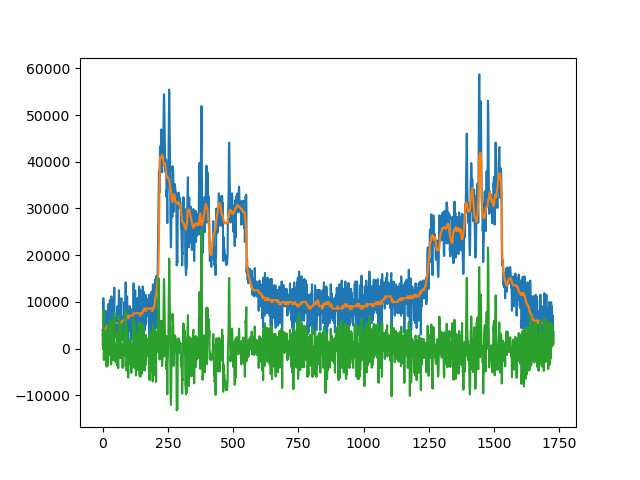

In [13]:
fig = plt.figure()
plt.plot(a)
plt.plot(b)
plt.plot(a-b)

In [14]:
a = np.array(dater,dtype=np.float32)
b = np.array(scipy.signal.medfilt(dater,15),dtype=np.float32)
c = np.array(scipy.signal.medfilt(dater,3),dtype=np.float32)

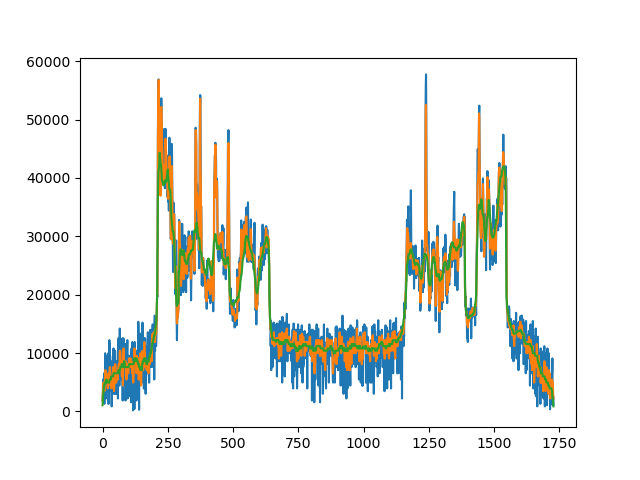

In [15]:
fig = plt.figure()
plt.plot(a[1000])
plt.plot(c[1000])
plt.plot(b[1000])

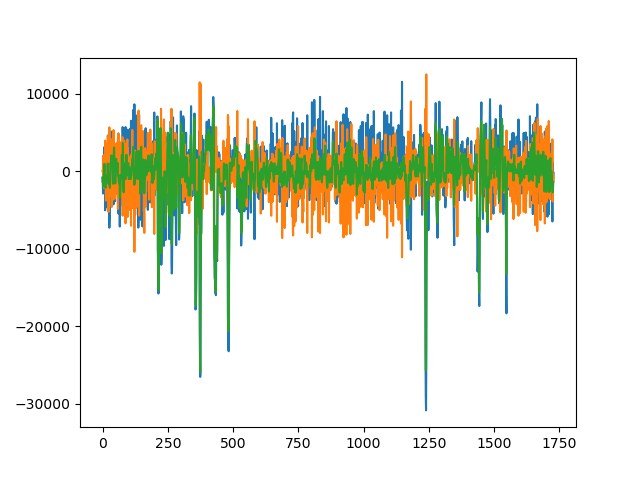

In [17]:
fig = plt.figure()
e = b[1000]-a[1000]
f = a[1000]-c[1000]
plt.plot(b[1000]-a[1000])
plt.plot(a[1000]-c[1000])
plt.plot(e+f)

/tmp/ipykernel_11871/809866730.py:1: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure()


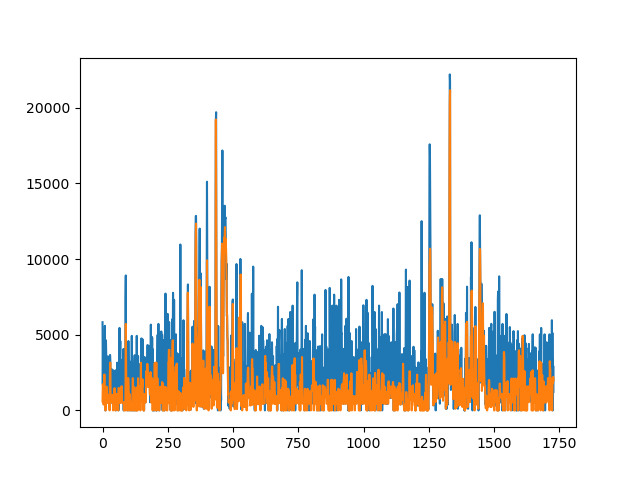

In [35]:
fig = plt.figure()
plt.plot(np.abs(a[500]-b[500]))
plt.plot(np.abs((b-a)+(a-c))[500])

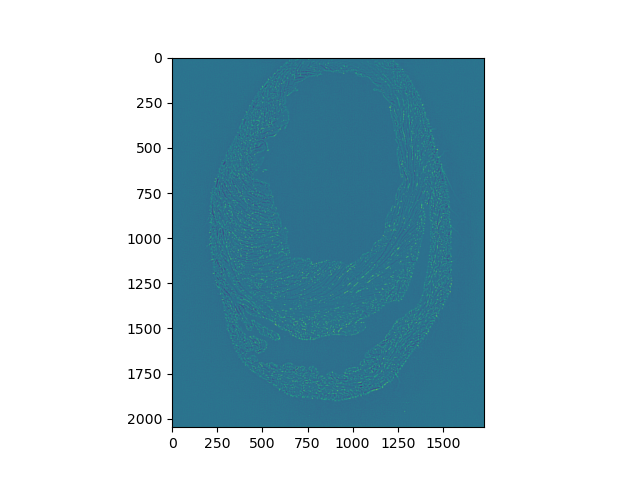

In [ ]:
fig = plt.figure()
plt.imshow(a-b)

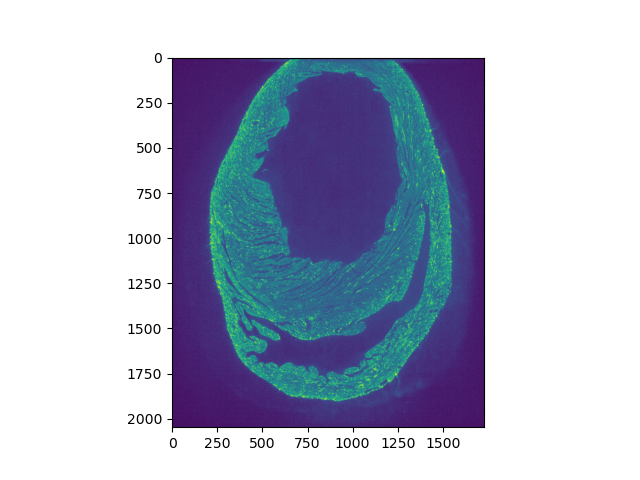

In [19]:
fig = plt.figure()
plt.imshow(a)

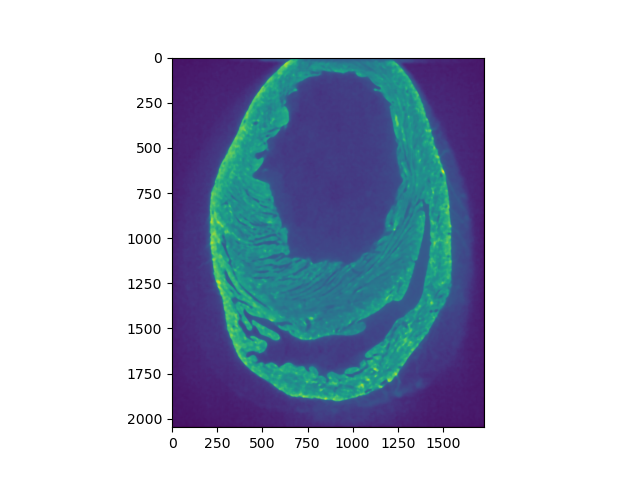

In [20]:
fig = plt.figure()
plt.imshow(b)

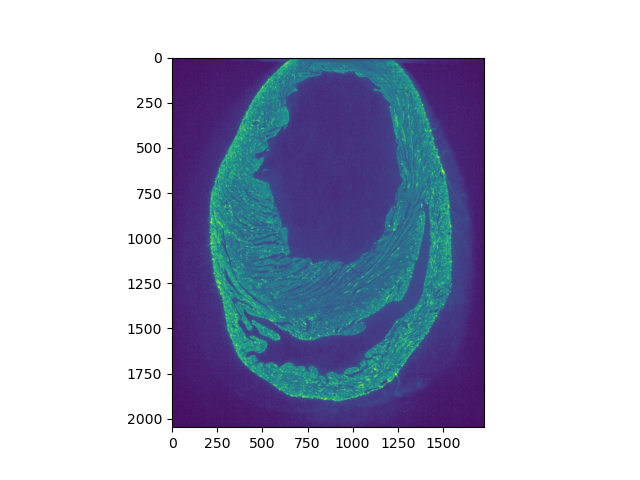

In [21]:
fig = plt.figure()
plt.imshow(c)

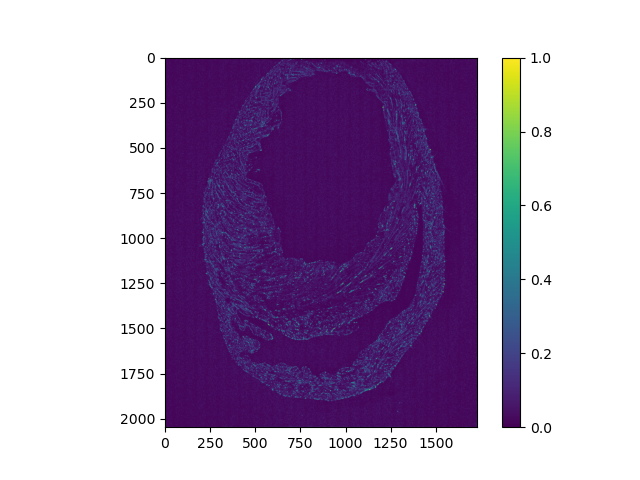

In [29]:
fig = plt.figure()
plt.imshow((np.abs((b-a)+(a-c)))/np.nanmax(np.abs((b-a)+(a-c))))
plt.colorbar()

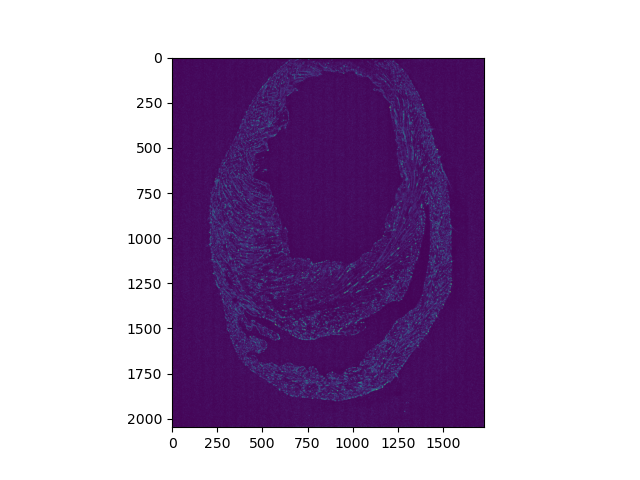

In [ ]:
fig = plt.figure()
plt.imshow(specialSauce(dater,3,15))

In [ ]:
a = specialSauce(dater,3,15)

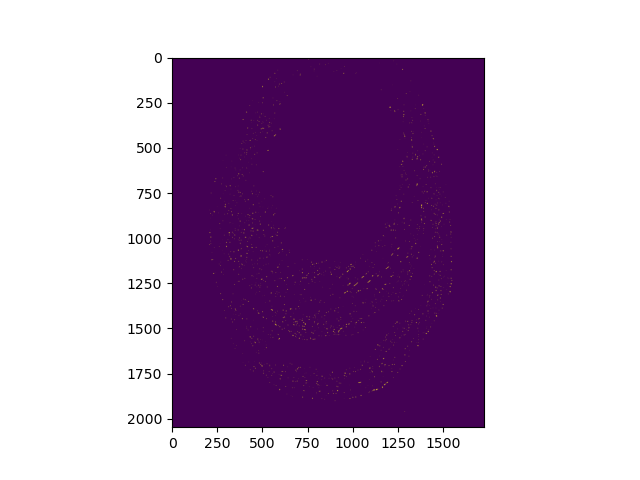

In [ ]:
fig = plt.figure()
plt.imshow(to1Bit(blackpoint(a,np.nanpercentile(a,99.7))))

In [ ]:
plt.imshow(to1Bit(blackpoint(dater,np.nanpercentile(scipy.signal.medfilt(dater),99.9))))

In [ ]:
clahe = cv2.createCLAHE(clipLimit=.01,tileGridSize=(1, 1))
clahe_img = clahe.apply(dater)
plt.imshow(clahe_img-scipy.signal.medfilt(clahe_img))

In [ ]:
plt.imshow(normalize(clahe_img))

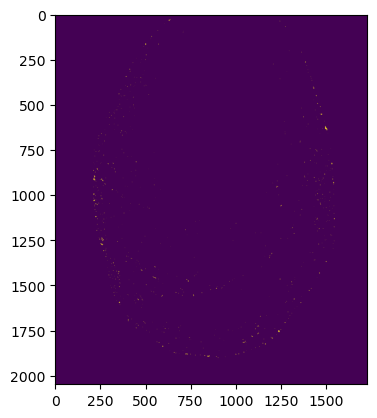

In [ ]:
plt.imshow(to1Bit(blackpoint(dater,np.nanpercentile(dater,99.9))))

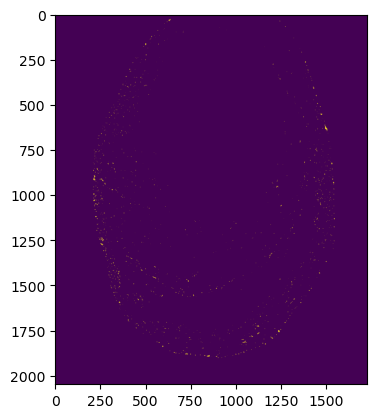

In [ ]:
plt.imshow(np.pad(to1Bit(blackpoint(clahe_img,np.nanpercentile(clahe_img,99.8))),pad_width=((0, 0), (0, 0)), 
                      mode='constant', 
                      constant_values=0))

In [ ]:
np.pad(to1Bit(blackpoint(clahe_img,np.nanpercentile(clahe_img,99.7))),pad_width=((0, 0), (0, 400)), mode='constant', constant_values=0).shape

(2560, 2560)

In [ ]:
arr = np.array(normalize(clahe_img),dtype=np.uint8)
arr = np.array(to1Bit(blackpoint(clahe_img,np.nanpercentile(clahe_img,99.7))),dtype=np.bool)

In [ ]:
arr

array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]],
      shape=(2048, 1728))

In [ ]:
f = tifffile.imread('/home/thomas/Desktop/tester.tiff')

In [ ]:
np.max(f)

np.int64(63488)

In [ ]:
np.max(normalize(clahe_img))

np.int64(248)

In [ ]:
tifffile.imwrite('/home/thomas/Desktop/tester.tiff',arr)

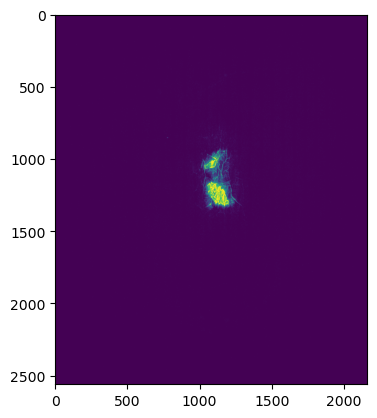

In [ ]:
plt.imshow(blackpoint(clahe_img,np.nanpercentile(clahe_img,95)))

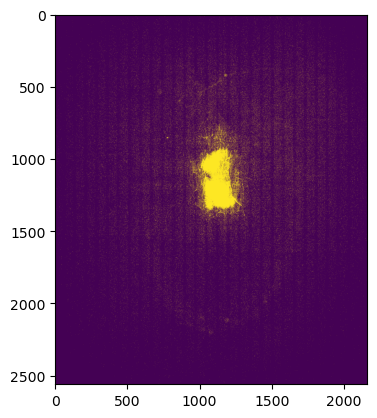

In [ ]:
plt.imshow(to1Bit(blackpoint(clahe_img,np.nanpercentile(clahe_img,95))))

In [ ]:
dater1

array([[2, 1, 1, ..., 0, 0, 1],
       [1, 1, 1, ..., 0, 1, 2],
       [0, 0, 2, ..., 0, 3, 2],
       ...,
       [1, 2, 1, ..., 0, 1, 1],
       [1, 1, 1, ..., 5, 3, 0],
       [1, 1, 0, ..., 0, 3, 0]], shape=(2560, 2160))

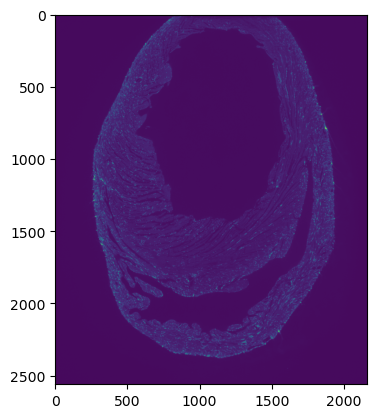

In [ ]:
plt.imshow((asinh_transform(dater,500)))

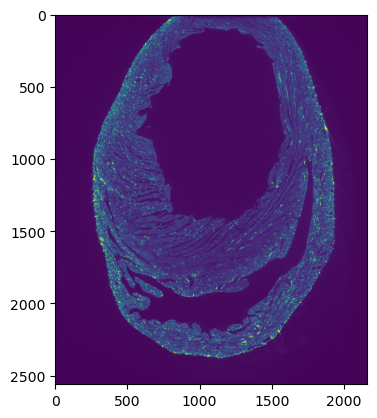

In [ ]:
plt.imshow(dater1)

In [ ]:
for file in flist[:]:
    dater = tifffile.imread(file)
    tifffile.imwrite(f'/home/thomas/Desktop/streched/{file}',np.array(normalize(asinh_transform(dater,150)),dtype=np.uint8))

In [ ]:
len(flist)

101

In [ ]:
a = np.array(normalize(asinh_transform(dater,150)),dtype=np.uint8)

In [ ]:
flist[4][-70:]

'18-49-22_640_667_4239_1_63_6_rl_bl_UltraII_C02_xyz-Table Z0005.ome.tif'

In [ ]:
# Define a function for processing each file
def process_file(f, output_dir):
    # Read the file
    dater = tifffile.imread(f)
    
    # Process the file using your specialSauce and other functions
    arr = specialSauce(dater, 3, 15)
    processed_arr = blackpoint(arr, np.nanpercentile(arr, 99.7))
    final_arr = to1Bit(processed_arr)
    
    # Write the processed data to a new file
    output_path = f'{output_dir}/{f[-70:]}'
    tifffile.imwrite(output_path, final_arr)
    print(f'Processed: {f[-70:]}')
output_dir = '/home/thomas/Desktop/strechedC02'

In [ ]:
with ThreadPoolExecutor() as executor:
    # Submit a task for each file in the list
    futures = [executor.submit(process_file, f, output_dir) for f in flist]

    # Optionally, wait for all futures to finish
    for future in futures:
        future.result()  # This will raise exceptions if any thread fails


Processed: 18-49-22_640_667_4239_1_63_6_rl_bl_UltraII_C02_xyz-Table Z0008.ome.tif
Processed: 18-49-22_640_667_4239_1_63_6_rl_bl_UltraII_C02_xyz-Table Z0004.ome.tif
Processed: 18-49-22_640_667_4239_1_63_6_rl_bl_UltraII_C02_xyz-Table Z0017.ome.tif
Processed: 18-49-22_640_667_4239_1_63_6_rl_bl_UltraII_C02_xyz-Table Z0020.ome.tif
Processed: 18-49-22_640_667_4239_1_63_6_rl_bl_UltraII_C02_xyz-Table Z0002.ome.tif
Processed: 18-49-22_640_667_4239_1_63_6_rl_bl_UltraII_C02_xyz-Table Z0012.ome.tif
Processed: 18-49-22_640_667_4239_1_63_6_rl_bl_UltraII_C02_xyz-Table Z0005.ome.tif
Processed: 18-49-22_640_667_4239_1_63_6_rl_bl_UltraII_C02_xyz-Table Z0011.ome.tif
Processed: 18-49-22_640_667_4239_1_63_6_rl_bl_UltraII_C02_xyz-Table Z0016.ome.tif
Processed: 18-49-22_640_667_4239_1_63_6_rl_bl_UltraII_C02_xyz-Table Z0018.ome.tif
Processed: 18-49-22_640_667_4239_1_63_6_rl_bl_UltraII_C02_xyz-Table Z0019.ome.tif
Processed: 18-49-22_640_667_4239_1_63_6_rl_bl_UltraII_C02_xyz-Table Z0001.ome.tif
Processed: 18-49

In [ ]:
le = len(flist)
for ind,f in enumerate(flist[:]):
    print(f'{ind} / {le}' ,end='\r')
    dater = tifffile.imread(f)
    arr = specialSauce(dater,3,15)
    tifffile.imwrite(f'/home/thomas/Desktop/strechedC02/{f[-70:]}',to1Bit(blackpoint(arr,np.nanpercentile(arr,99.5))))

KeyboardInterrupt: 

In [ ]:
file[-70:]

'18-49-22_640_667_4239_1_63_6_rl_bl_UltraII_C02_xyz-Table Z0001.ome.tif'

In [ ]:
clahe_img = clahe.apply(dater)

NameError: name 'clahe' is not defined

In [ ]:
flist[5][31:]

'18-49-22_640_667_4239_1_63_6_rl_bl_UltraII_C02_xyz-Table Z0006.ome.tif'

In [ ]:
clahe_img.shape

NameError: name 'clahe_img' is not defined

In [ ]:
f[30:]

NameError: name 'f' is not defined

In [ ]:
le = len(flist)
for ind,f in enumerate(flist[:]):
    print(f'{ind} / {le}' ,end='\r')
    dater = tifffile.imread(f)
    clahe_img = clahe.apply(dater)
    arr = np.pad(to1Bit(blackpoint(clahe_img,np.nanpercentile(clahe_img,99.1))),pad_width=((0, 0), (0, 400)), mode='constant', constant_values=0)
    tifffile.imwrite(f'/home/thomas/Desktop/strechedC02/{f[31:]}',arr)